In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import QTable
from sunpy.time import TimeRange

from hermpy.data import parse_messenger_fips, parse_messenger_mag
from hermpy.net import ClientMESSENGER
from hermpy.plotting import MultiPanel, SpectrogramPanel, TimeseriesPanel

import matplotlib.pyplot as plt
from matplotlib import colormaps as cm
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.colors import Normalize
from PIL import Image

/home/ocean/dias_internship/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Download MESSENGER data
Initiate MESSENGER client and define a time range in which you want to download your data from.

In [3]:
c = ClientMESSENGER()
time_range_1_hour = TimeRange("2011-09-27T12:00", "2011-09-27T13:00")
time_range_2_hour = TimeRange("2011-09-27T12:00", "2011-09-27T14:00")
time_range_8_hour = TimeRange("2011-09-27T12:00", "2011-09-27T20:00")

mag_data = {}

c.query(time_range_1_hour, "MAG")
all_mag_data_1_hour = c.fetch()

c.query(time_range_2_hour, "MAG")
all_mag_data_2_hour = c.fetch()

c.query(time_range_8_hour, "MAG")
all_mag_data_8_hour = c.fetch()

mag_data[0]: QTable = parse_messenger_mag(all_mag_data_1_hour, time_range_1_hour)
mag_data[1]: QTable = parse_messenger_mag(all_mag_data_2_hour, time_range_2_hour)
mag_data[2]: QTable = parse_messenger_mag(all_mag_data_8_hour, time_range_8_hour)


Take magnetic and positional data from time ranges

In [4]:
def total_mag_field(data):
    total_data = data["UTC", "Bx", "By", "Bz"]
    total_mag_data = np.sqrt(total_data["Bx"]**2 + total_data["Bx"]**2 + total_data["Bz"]**2)
    mag_field_data = QTable(data=[data["UTC"], total_mag_data], names=["UTC", "|B|"])
    return total_data, mag_field_data

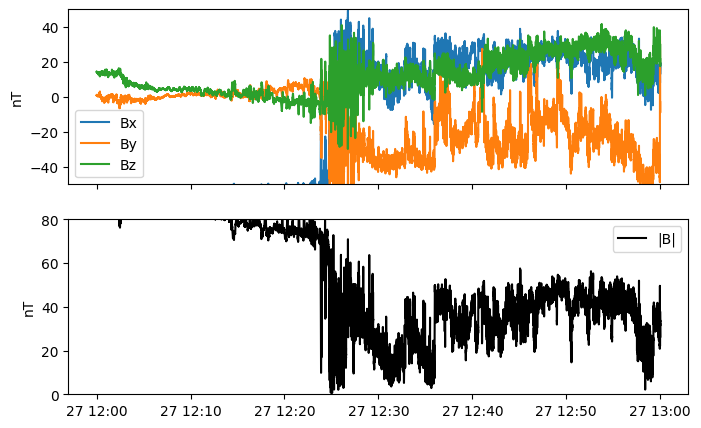

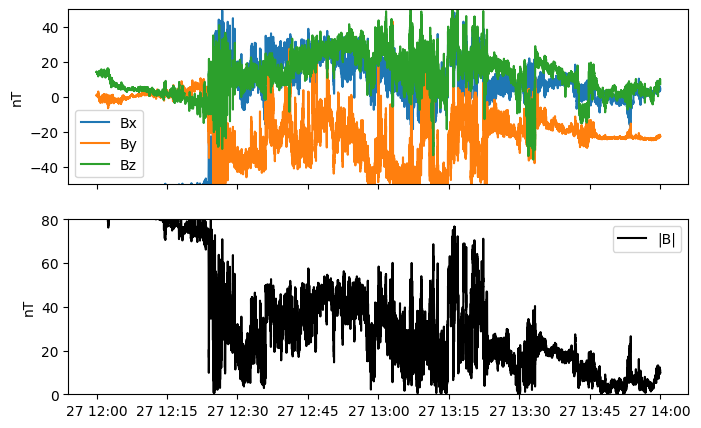

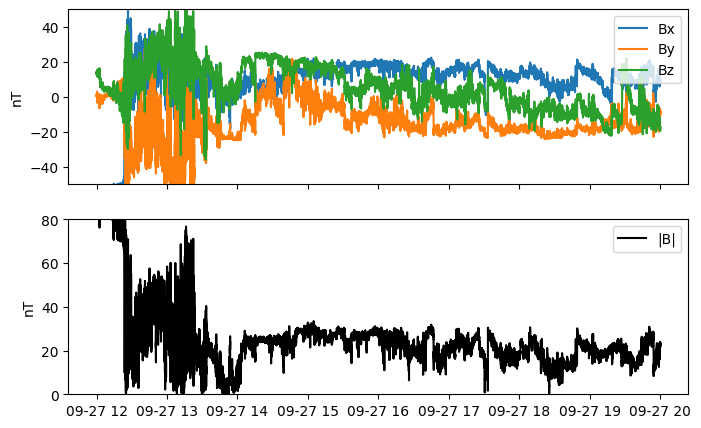

In [5]:
mag_plotting_data = {}
mag_panels = {}
for i in mag_data:
    mag_plotting_data[i] = total_mag_field(mag_data[i])
    mag_panels[i] = TimeseriesPanel(mag_plotting_data[i][0]) + TimeseriesPanel(mag_plotting_data[i][1])
    fig, ax = mag_panels[i].plot(show=False)
    lines = ax[1].get_lines()
    lines[0].set_color('k')
    ax[1].legend()
    ax[0].set_ylim(-50,50)
    ax[1].set_ylim(0,80)
    plt.show()
    

In [6]:
print(mag_plotting_data[2][0]["UTC"].to_datetime(leap_second_strict="warn"))
print(mag_plotting_data[2][0]["UTC"])

[datetime.datetime(2011, 9, 27, 12, 0, 0, 21000)
 datetime.datetime(2011, 9, 27, 12, 0, 0, 71000)
 datetime.datetime(2011, 9, 27, 12, 0, 0, 121000) ...
 datetime.datetime(2011, 9, 27, 19, 59, 58, 628000)
 datetime.datetime(2011, 9, 27, 19, 59, 59, 128000)
 datetime.datetime(2011, 9, 27, 19, 59, 59, 628000)]
['2011:270:12:00:00.021' '2011:270:12:00:00.071' '2011:270:12:00:00.121'
 ... '2011:270:19:59:58.628' '2011:270:19:59:59.128'
 '2011:270:19:59:59.628']


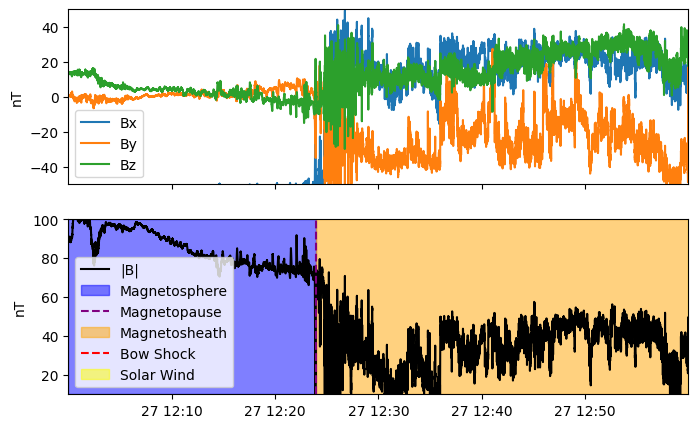

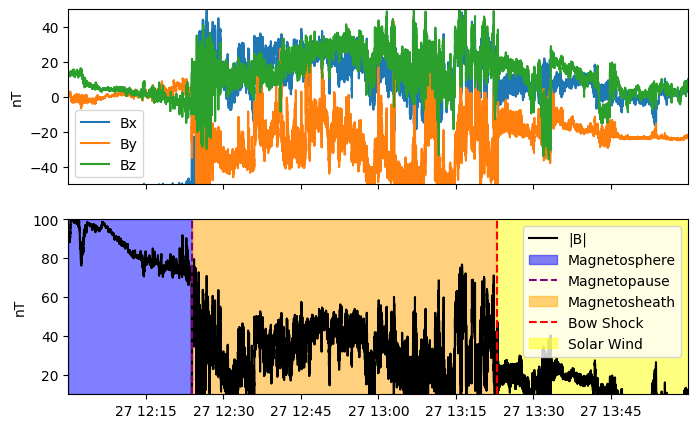

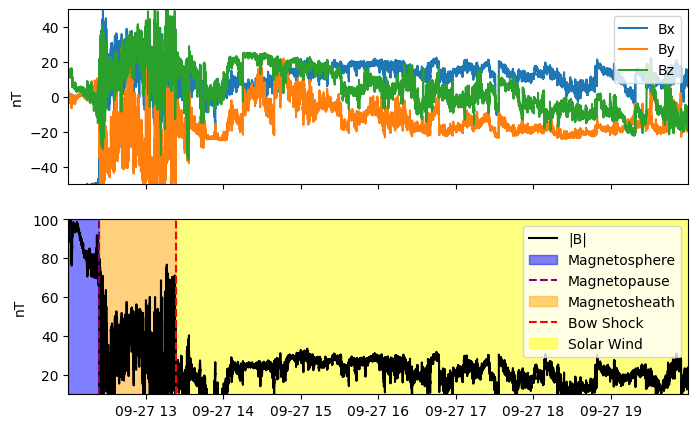

In [9]:
import datetime

for i in mag_panels:
    fig, ax = mag_panels[i].plot(show=False)

    lines = ax[1].get_lines()
    lines[0].set_color('k')
    lines = ax[1].get_lines()
    lines[0].set_color('k')

    ax[0].set_ylim(-50,50)
    ax[1].set_ylim(10,100)

    ax[0].set_xlim(mag_plotting_data[i][1]["UTC"][0].to_datetime(leap_second_strict="warn"), mag_plotting_data[i][1]["UTC"][-1].to_datetime(leap_second_strict="warn"))
    ax[1].set_xlim(mag_plotting_data[i][1]["UTC"][0].to_datetime(leap_second_strict="warn"), mag_plotting_data[i][1]["UTC"][-1].to_datetime(leap_second_strict="warn"))

    magnetospheretime1 = datetime.datetime(2011, 9, 27, 12, 0, 0, 21000)
    magnetospheretime2 = datetime.datetime(2011, 9, 27, 12, 24, 0, 00000)

    ax[1].axvspan(magnetospheretime1, magnetospheretime2, alpha =0.5, color='blue', label='Magnetosphere')
    ax[1].vlines(magnetospheretime2, 10, 100, ls='--', color='purple', label='Magnetopause')
    
    magnetosheathtime = datetime.datetime(2011, 9, 27, 13, 23, 0, 21000)
    ax[1].axvspan(magnetospheretime2, magnetosheathtime, alpha =0.5, color='orange', label='Magnetosheath')
    ax[1].vlines(magnetosheathtime, 10, 100, ls='--', color='red', label='Bow Shock')
    
    solarwindtime = mag_plotting_data[i][1]["UTC"][-1].to_datetime(leap_second_strict="warn")

    ax[1].axvspan(magnetosheathtime, solarwindtime, alpha =0.5, color='yellow', label='Solar Wind')

    ax[1].legend()
    plt.show()